In [2]:
import numpy as np
import matplotlib.pyplot as plt

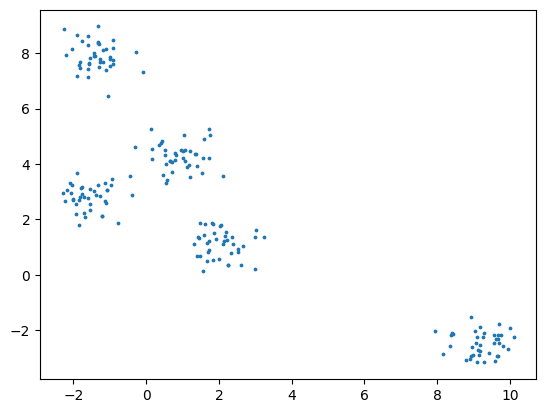

In [43]:
from sklearn.datasets import make_blobs
X, y = make_blobs(
    n_samples=200, 
    n_features=2, 
    centers=5, 
    cluster_std=0.5,
    random_state=0,
    )

plt.scatter(X[:, 0], X[:, 1], s=3)
plt.show()

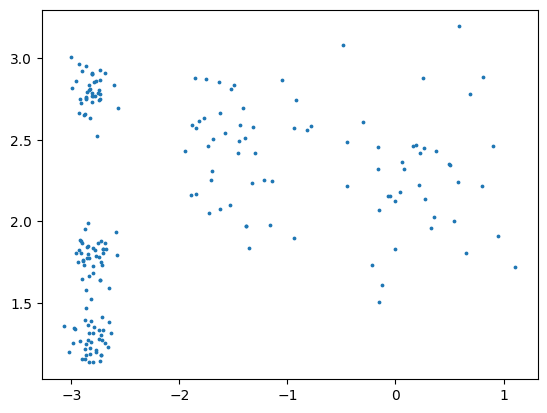

In [122]:
blob_center = np.array([
    [ 0.2,  2.3], 
	[-1.5,  2.3], 
	[-2.8,  1.8],
	[-2.8,  2.8], 
	[-2.8,  1.3]
])

blob_std = np.array(
    [0.4, 0.3, 0.1, 0.1, 0.1]
)

X, y = make_blobs(
    n_samples=200, 
    n_features=2, 
    centers=blob_center, 
    cluster_std=blob_std,
    random_state=0,
    )

plt.scatter(X[:, 0], X[:, 1], s=3)
plt.show()

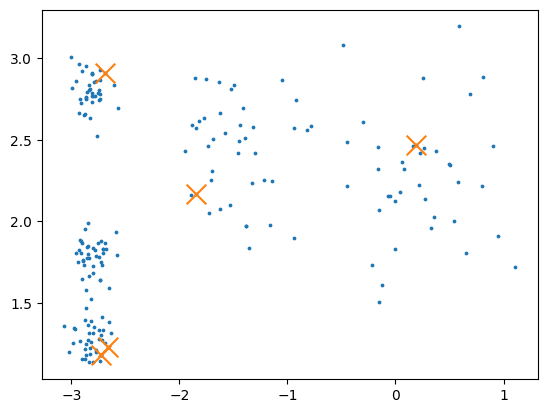

In [205]:
K = 5

rng = np.random.default_rng(137)
centroids = rng.choice(X, size=K, replace=False)

plt.scatter(X[:, 0], X[:, 1], s=3)
plt.scatter(centroids[:, 0], centroids[:, 1], 
            marker='x', s=200)
plt.show()

In [207]:
rng = np.random.default_rng(136)

def initialize_centroid(X, K, rng):

	centroids = rng.choice(X, size=K, replace=False)

	return centroids

initialize_centroid(X, 5, rng)

array([[-2.69003404,  1.86552637],
       [-0.12525851,  1.60948696],
       [-1.73097482,  2.46177476],
       [-1.63054607,  2.85477912],
       [-2.7476109 ,  2.80884221]])

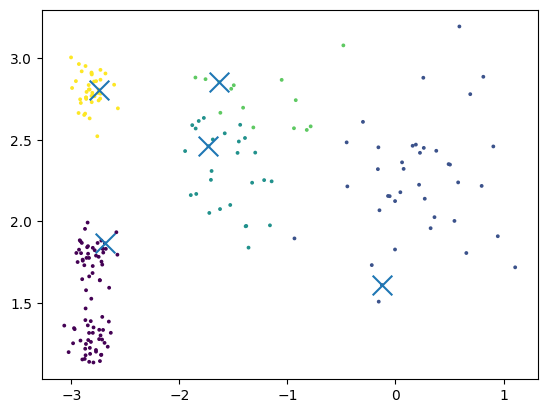

In [171]:
from sklearn.metrics import pairwise_distances, pairwise_distances_argmin
# pairwise_distances(X, centroids).round(2)
y_pred = pairwise_distances_argmin(X, centroids)

plt.scatter(X[:, 0], X[:, 1], s=3, c=y_pred)
plt.scatter(centroids[:, 0], centroids[:, 1],
            marker='x', s=200)
plt.show()

In [ ]:
def assign_clusters(X, centroids):
	y_pred = pairwise_distances_argmin(X, centroids)

	return y_pred

assign_clusters(X, centroids)

array([1, 0, 1, 0, 0, 1, 3, 0, 0, 1, 4, 0, 4, 2, 4, 0, 2, 0, 2, 0, 4, 2,
       3, 4, 4, 3, 0, 0, 1, 2, 2, 3, 4, 1, 0, 0, 4, 0, 0, 1, 1, 3, 3, 4,
       4, 0, 0, 0, 1, 0, 0, 1, 4, 2, 4, 0, 0, 0, 3, 4, 4, 0, 0, 2, 0, 2,
       2, 4, 1, 0, 0, 0, 0, 4, 4, 1, 0, 2, 1, 1, 0, 2, 2, 0, 4, 4, 1, 0,
       3, 1, 4, 0, 0, 0, 1, 0, 1, 4, 1, 0, 1, 1, 0, 1, 0, 2, 4, 4, 1, 0,
       2, 0, 0, 0, 0, 0, 2, 1, 4, 4, 4, 3, 0, 0, 0, 2, 0, 1, 2, 3, 2, 1,
       0, 4, 4, 1, 4, 0, 1, 4, 0, 2, 0, 0, 4, 0, 1, 0, 0, 0, 3, 1, 4, 0,
       2, 3, 0, 0, 0, 0, 1, 0, 1, 4, 4, 0, 2, 0, 2, 2, 2, 0, 0, 0, 1, 4,
       2, 1, 2, 0, 0, 4, 0, 0, 3, 0, 0, 0, 4, 1, 3, 1, 1, 4, 0, 4, 1, 0,
       1, 4])

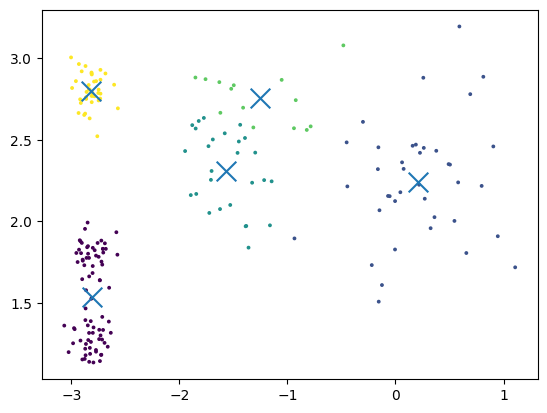

In [191]:
new_centroids = []

for i in range(K):
    new_centroid = X[y_pred == i].mean(axis=0)
    new_centroids.append(new_centroid)
    
new_centroids = np.array(new_centroids)

plt.scatter(X[:, 0], X[:, 1], s=3, c=y_pred)
plt.scatter(new_centroids[:, 0], new_centroids[:, 1],
            marker='x', s=200)
plt.show()

In [192]:
def update_centroids(X, y_pred, K):

	new_centroids = []

	for i in range(K):
		new_centroid = X[y_pred == i].mean(axis=0)
		new_centroids.append(new_centroid)
		
	new_centroids = np.array(new_centroids)

	return new_centroids

update_centroids(X, y_pred, 5)

array([[-2.80960127,  1.53369206],
       [ 0.21093603,  2.24150527],
       [-1.56750512,  2.3113385 ],
       [-1.25789755,  2.75798545],
       [-2.81954677,  2.80136085]])

array([[ 0.12917995,  2.02328376],
       [-2.80960127,  1.53369206],
       [-2.81954677,  2.80136085],
       [-1.47282319,  2.43495849],
       [ 0.3314596 ,  2.56191025]])

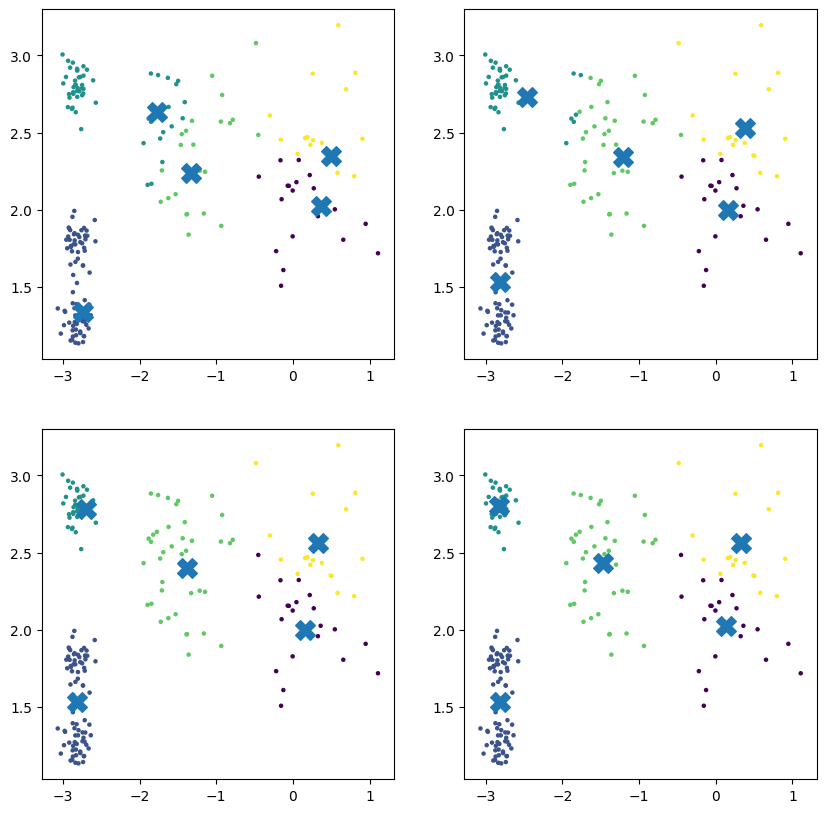

In [208]:
max_iter = 4
K=5
rng = np.random.default_rng(139)
centroids = initialize_centroid(X,K,rng)

fig, axs = plt.subplots(2,2, figsize=(10,10))

for j in range(max_iter):
	y_pred = assign_clusters(X, centroids)
	new_centroids = update_centroids(X, y_pred, K)

	axs.flatten()[j].scatter(X[:, 0], X[:, 1], s=5, c=y_pred)
	axs.flatten()[j].scatter(centroids[:, 0], centroids[:, 1], s=200, marker='X')
    
	centroids = new_centroids

centroids

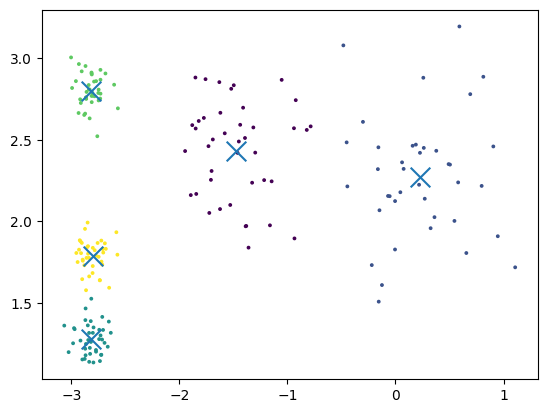

In [220]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=5, random_state =10)
y_pred = km.fit_predict(X)


plt.scatter(X[:, 0], X[:, 1], s=3, c=y_pred)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            marker='x', s=200)
plt.show()